In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from utility_functions import *

In [22]:
data_features_df = pd.read_csv("data_features_df_selected.csv")

In [23]:
data_features_df.columns

Index(['Date', 'Id', 'y', 'weight', 'cum_return_prev5d', 'cum_return_prev21d',
       'cum_return_prev63d', 'cum_return_prev1d', 'cum_return_09:30_10:00',
       'cum_return_10:00_11:30', 'cum_return_11:30_13:30',
       'cum_return_13:30_15:15', 'relative_volume_prev09:30_11:30',
       'relative_volume_prev11:30_13:30', 'relative_volume_prev13:30_16:00',
       'relative_volume_09:30_10:00', 'relative_volume_10:00_11:30',
       'relative_volume_11:30_13:30', 'relative_volume_13:30_15:30',
       'volume_resid_return_corr', 'volume_raw_return_corr', 'volatility_1d',
       'volatility_21d_raw', 'volatility_21d_resid', 'volatility_63d_raw',
       'volatility_63d_resid', 'skewness_1d', 'skewness_21d_resid',
       'skewness_63d_resid'],
      dtype='object')

In [24]:
feature_columns = ['cum_return_prev5d', 'cum_return_prev21d',
       'cum_return_prev63d', 'cum_return_prev1d', 'cum_return_09:30_10:00',
       'cum_return_10:00_11:30', 'cum_return_11:30_13:30',
       'cum_return_13:30_15:15', 'relative_volume_prev09:30_11:30',
       'relative_volume_prev11:30_13:30', 'relative_volume_prev13:30_16:00',
       'relative_volume_09:30_10:00', 'relative_volume_10:00_11:30',
       'relative_volume_11:30_13:30', 'relative_volume_13:30_15:30',
       'volume_resid_return_corr', 'volume_raw_return_corr', 'volatility_1d',
       'volatility_21d_raw', 'volatility_21d_resid', 'volatility_63d_raw',
       'volatility_63d_resid', 'skewness_1d', 'skewness_21d_resid',
       'skewness_63d_resid']

In [25]:
feature_columns

['cum_return_prev5d',
 'cum_return_prev21d',
 'cum_return_prev63d',
 'cum_return_prev1d',
 'cum_return_09:30_10:00',
 'cum_return_10:00_11:30',
 'cum_return_11:30_13:30',
 'cum_return_13:30_15:15',
 'relative_volume_prev09:30_11:30',
 'relative_volume_prev11:30_13:30',
 'relative_volume_prev13:30_16:00',
 'relative_volume_09:30_10:00',
 'relative_volume_10:00_11:30',
 'relative_volume_11:30_13:30',
 'relative_volume_13:30_15:30',
 'volume_resid_return_corr',
 'volume_raw_return_corr',
 'volatility_1d',
 'volatility_21d_raw',
 'volatility_21d_resid',
 'volatility_63d_raw',
 'volatility_63d_resid',
 'skewness_1d',
 'skewness_21d_resid',
 'skewness_63d_resid']

In [26]:
# 创建包含重要特征的列表
important_features = [
    "cum_return_prev1d",
    "cum_return_10:00_11:30",
    "relative_volume_13:30_15:30",
    "volume_resid_return_corr",
    "volume_raw_return_corr",
    "volatility_1d",
    "skewness_1d",
]

# 输出列表
important_features


['cum_return_prev1d',
 'cum_return_10:00_11:30',
 'relative_volume_13:30_15:30',
 'volume_resid_return_corr',
 'volume_raw_return_corr',
 'volatility_1d',
 'skewness_1d']

In [27]:
data_features_df.iloc[452341,:]

Date                                 2014-01-02
Id                                 BBG000B9WH86
y                                      0.006959
weight                             14512.155595
cum_return_prev5d                       0.02111
cum_return_prev21d                     0.027143
cum_return_prev63d                     0.117363
cum_return_prev1d                       0.00119
cum_return_09:30_10:00                 0.002382
cum_return_10:00_11:30                -0.002449
cum_return_11:30_13:30                 0.011824
cum_return_13:30_15:15                 0.000768
relative_volume_prev09:30_11:30        0.290214
relative_volume_prev11:30_13:30        0.152236
relative_volume_prev13:30_16:00        0.283083
relative_volume_09:30_10:00            0.232793
relative_volume_10:00_11:30            0.607023
relative_volume_11:30_13:30            0.212069
relative_volume_13:30_15:30            0.222949
volume_resid_return_corr               -0.38003
volume_raw_return_corr                 0

In [28]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. 加载数据集
X = data_features_df[feature_columns]
y = data_features_df['y']  # 目标变量
weights = data_features_df['weight']

In [29]:
print(y.describe())

count    574925.000000
mean         -0.000013
std           0.014562
min          -0.790887
25%          -0.005721
50%          -0.000200
75%           0.005488
max           1.943941
Name: y, dtype: float64


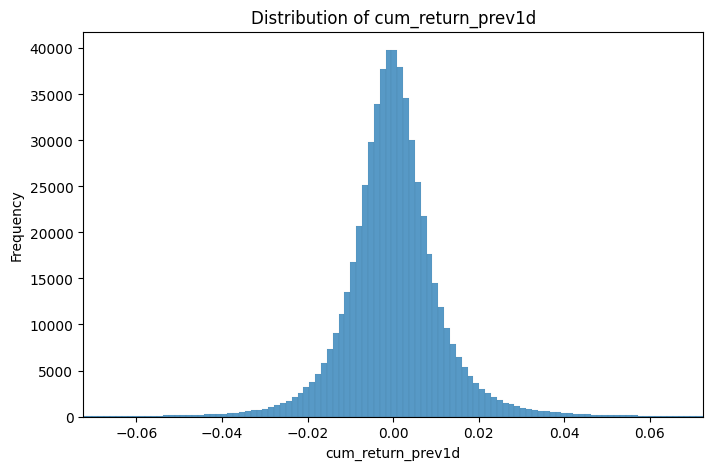

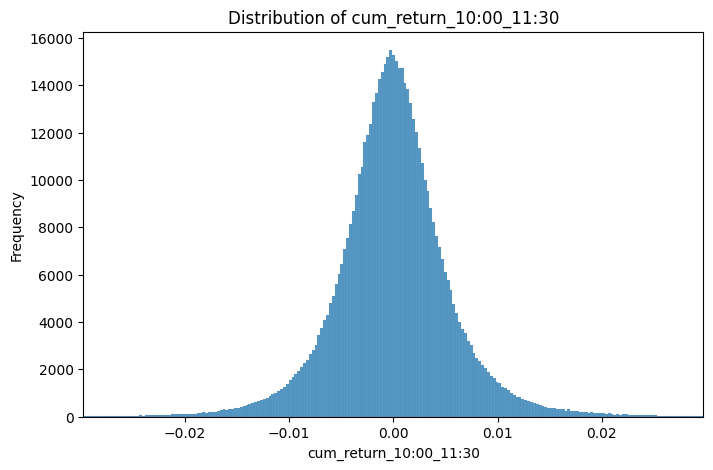

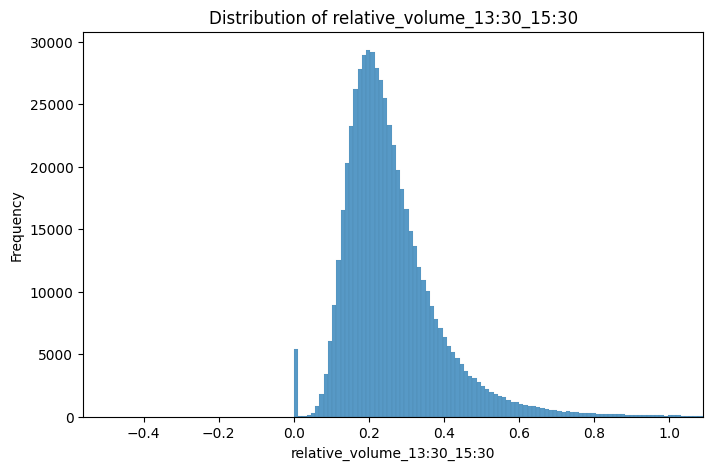

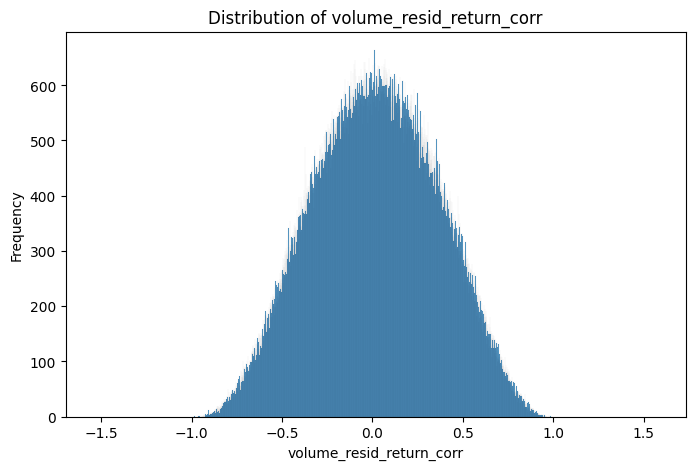

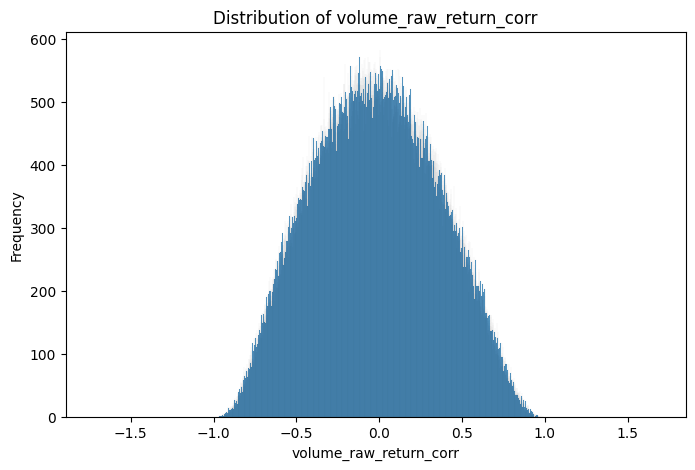

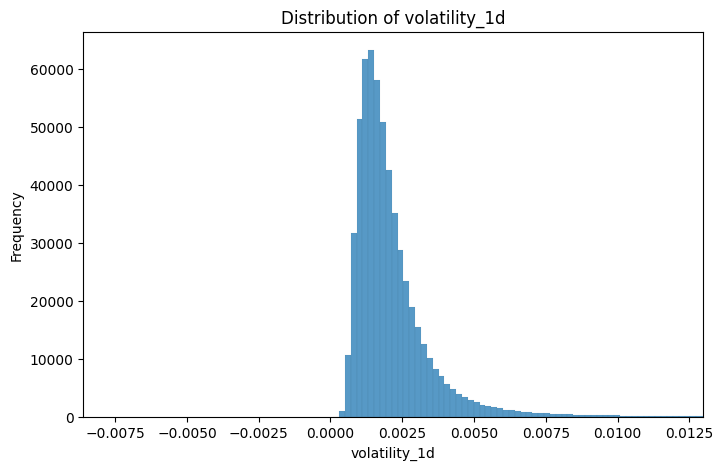

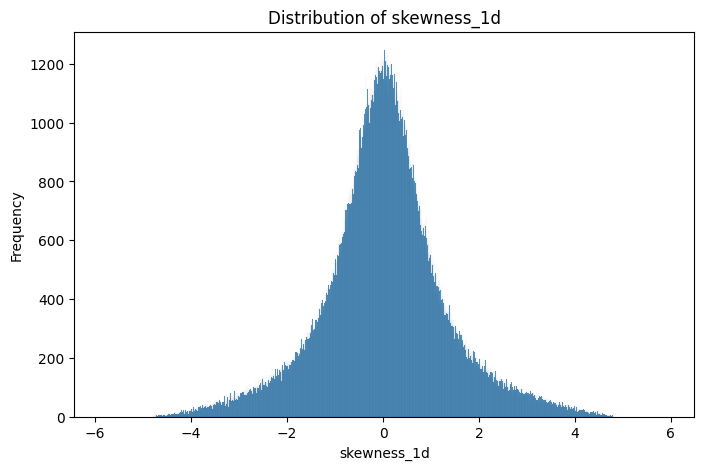

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in important_features:  # 修正变量名
    plt.figure(figsize=(8, 5))
    
    x = data_features_df[feature]  # 选择当前 feature 的数据
    sns.histplot(x, bins=2000)  # kde=True 添加密度曲线
    
    plt.xlim(x.mean() - 5 * x.std(), x.mean() + 5 * x.std())  # 调整 x 轴范围
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature}")  # 动态标题
    
    plt.show()


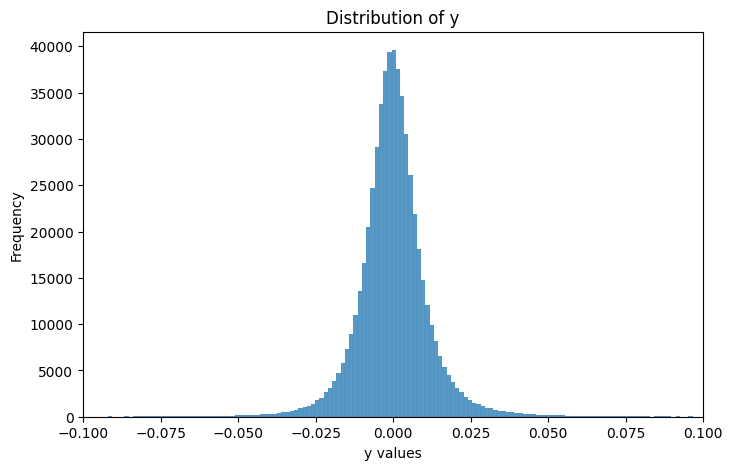

In [31]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(y, bins=2000)  # kde=True 添加密度曲线
plt.xlim(-0.1, 0.1)  # 调整 x 轴范围
plt.xlabel('y values')
plt.ylabel('Frequency')
plt.title('Distribution of y')
plt.show()


In [15]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore

# 1. 计算 y 的 Z-score 标准化
y_mean = y.mean()
y_std = y.std()
y_z = (y - y_mean) / y_std  # 计算Z-score
y_z = np.clip(y_z, -5, 5)  # 裁剪超过5个标准差的值

# 2. 训练集和测试集划分
X_train, X_test = X.loc[:452341, :], X.loc[452341:, :]
y_train, y_test = y_z.loc[:452341], y_z.loc[452341:]
weights_train, weights_test = weights.loc[:452341], weights.loc[452341:]

# 3. 训练初始随机森林模型
start_time = time.time()
rf = RandomForestRegressor(n_jobs=-1, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"初始模型 训练时间: {training_time:.2f} 秒")

# 4. 预测 & 评估（在 Z-score 空间）
y_train_pred_z = rf.predict(X_train)
y_test_pred_z = rf.predict(X_test)

# 反映射回原始 y 值
y_train_pred = y_train_pred_z * y_std + y_mean
y_test_pred = y_test_pred_z * y_std + y_mean

# 处理超出范围的值
y_train_pred = np.where(y_train_pred_z > 5, y_mean + 5 * y_std, y_train_pred)
y_train_pred = np.where(y_train_pred_z < -5, y_mean - 5 * y_std, y_train_pred)

y_test_pred = np.where(y_test_pred_z > 5, y_mean + 5 * y_std, y_test_pred)
y_test_pred = np.where(y_test_pred_z < -5, y_mean - 5 * y_std, y_test_pred)

# 计算加权 R²
def weighted_r2(y_true, y_pred, weights):
    numerator = np.sum(weights * (y_true - y_pred) ** 2)
    denominator = np.sum(weights * (y_true - np.average(y_true, weights=weights)) ** 2)
    return 1 - numerator / denominator

train_mse = mean_squared_error(y.loc[:452341], y_train_pred)
train_r2 = weighted_r2(y.loc[:452341], y_train_pred, weights_train)

test_mse = mean_squared_error(y.loc[452341:], y_test_pred)
test_r2 = weighted_r2(y.loc[452341:], y_test_pred, weights_test)

print(f"初始模型 训练集 MSE: {train_mse:.4f}, 训练集 加权 R²: {train_r2:.4f}")
print(f"初始模型 测试集 MSE: {test_mse:.4f}, 测试集 加权 R²: {test_r2:.4f}")

# 5. 设定超参数范围
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],
    'min_samples_split': [2, 5, 10]
}

# 6. 网格搜索 + 加权 R² 评分
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    y_pred_orig = y_pred * y_std + y_mean  # 反变换
    y_pred_orig = np.clip(y_pred_orig, y_mean - 5 * y_std, y_mean + 5 * y_std)  # 处理极值
    return weighted_r2(y, y_pred_orig, weights.loc[X.index])

start_time = time.time()
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring=custom_scorer,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
grid_search.fit(X_train, y_train)
grid_search_time = time.time() - start_time
print(f"网格搜索时间: {grid_search_time:.2f} 秒")

# 7. 保存搜索结果
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["Mean_Train_Weighted_R2"] = results_df["mean_train_score"]
results_df["Mean_Test_Weighted_R2"] = results_df["mean_test_score"]
results_df = results_df[["param_n_estimators", "param_max_depth", "param_min_samples_split",
                         "Mean_Train_Weighted_R2", "Mean_Test_Weighted_R2", "rank_test_score"]]
results_df = results_df.sort_values(by="Mean_Test_Weighted_R2", ascending=False)

print("\n所有参数组合的加权 R² 结果：")
print(results_df)

# 8. 训练最终模型
best_params = grid_search.best_params_
print("\n最佳参数:", best_params)

best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

# 9. 最终模型评估
y_train_best_pred_z = best_rf.predict(X_train)
y_test_best_pred_z = best_rf.predict(X_test)

# 反映射回原始 y
y_train_best_pred = y_train_best_pred_z * y_std + y_mean
y_test_best_pred = y_test_best_pred_z * y_std + y_mean

# 处理极值
y_train_best_pred = np.clip(y_train_best_pred, y_mean - 5 * y_std, y_mean + 5 * y_std)
y_test_best_pred = np.clip(y_test_best_pred, y_mean - 5 * y_std, y_mean + 5 * y_std)

# 计算最终加权 R²
final_train_mse = mean_squared_error(y.loc[:452341], y_train_best_pred)
final_train_r2 = weighted_r2(y.loc[:452341], y_train_best_pred, weights_train)

final_test_mse = mean_squared_error(y.loc[452341:], y_test_best_pred)
final_test_r2 = weighted_r2(y.loc[452341:], y_test_best_pred, weights_test)

print(f"\n优化后模型 训练集 MSE: {final_train_mse:.4f}, 训练集 加权 R²: {final_train_r2:.4f}")
print(f"优化后模型 测试集 MSE: {final_test_mse:.4f}, 测试集 加权 R²: {final_test_r2:.4f}")


初始模型 训练时间: 85.57 秒
初始模型 训练集 MSE: 0.0002, 训练集 加权 R²: 0.0287
初始模型 测试集 MSE: 0.0002, 测试集 加权 R²: 0.0001
Fitting 3 folds for each of 27 candidates, totalling 81 fits
网格搜索时间: 1485.16 秒

所有参数组合的加权 R² 结果：
   param_n_estimators param_max_depth param_min_samples_split  \
24                 50               5                      10   
18                 50               5                       2   
21                 50               5                       5   
15                 50               3                      10   
12                 50               3                       5   
9                  50               3                       2   
6                  50               2                      10   
0                  50               2                       2   
3                  50               2                       5   
25                100               5                      10   
10                100               3                       2   
14                200   

In [18]:
# 5. 设定超参数范围
param_grid = {
    'n_estimators': [50, 100, 200,300],
    'max_depth': [2, 5,10],
    'min_samples_split': [2, 5, 10]
}

# 6. 网格搜索 + 加权 R² 评分
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    y_pred_orig = y_pred * y_std + y_mean  # 反变换
    y_pred_orig = np.clip(y_pred_orig, y_mean - 5 * y_std, y_mean + 5 * y_std)  # 处理极值
    return weighted_r2(y, y_pred_orig, weights.loc[X.index])

start_time = time.time()
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring=custom_scorer,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
grid_search.fit(X_train, y_train)
grid_search_time = time.time() - start_time
print(f"网格搜索时间: {grid_search_time:.2f} 秒")

# 7. 保存搜索结果
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["Mean_Train_Weighted_R2"] = results_df["mean_train_score"]
results_df["Mean_Test_Weighted_R2"] = results_df["mean_test_score"]
results_df = results_df[["param_n_estimators", "param_max_depth", "param_min_samples_split",
                         "Mean_Train_Weighted_R2", "Mean_Test_Weighted_R2", "rank_test_score"]]
results_df = results_df.sort_values(by="Mean_Test_Weighted_R2", ascending=False)

print("\n所有参数组合的加权 R² 结果：")
print(results_df)

# 8. 训练最终模型
best_params = grid_search.best_params_
print("\n最佳参数:", best_params)

best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

# 9. 最终模型评估
y_train_best_pred_z = best_rf.predict(X_train)
y_test_best_pred_z = best_rf.predict(X_test)

# 反映射回原始 y
y_train_best_pred = y_train_best_pred_z * y_std + y_mean
y_test_best_pred = y_test_best_pred_z * y_std + y_mean

# 处理极值
y_train_best_pred = np.clip(y_train_best_pred, y_mean - 5 * y_std, y_mean + 5 * y_std)
y_test_best_pred = np.clip(y_test_best_pred, y_mean - 5 * y_std, y_mean + 5 * y_std)

# 计算最终加权 R²
final_train_mse = mean_squared_error(y.loc[:452341], y_train_best_pred)
final_train_r2 = weighted_r2(y.loc[:452341], y_train_best_pred, weights_train)

final_test_mse = mean_squared_error(y.loc[452341:], y_test_best_pred)
final_test_r2 = weighted_r2(y.loc[452341:], y_test_best_pred, weights_test)

print(f"\n优化后模型 训练集 MSE: {final_train_mse:.4f}, 训练集 加权 R²: {final_train_r2:.4f}")
print(f"优化后模型 测试集 MSE: {final_test_mse:.4f}, 测试集 加权 R²: {final_test_r2:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
网格搜索时间: 4542.49 秒

所有参数组合的加权 R² 结果：
   param_n_estimators param_max_depth param_min_samples_split  \
32                 50              10                      10   
28                 50              10                       5   
24                 50              10                       2   
20                 50               5                      10   
12                 50               5                       2   
16                 50               5                       5   
8                  50               2                      10   
33                100              10                      10   
0                  50               2                       2   
4                  50               2                       5   
30                200              10                       5   
34                200              10                      10   
29                100              10                    

In [19]:
# 5. 设定超参数范围
param_grid = {
    'n_estimators': [30,40,50,60],
    'max_depth': [8,10,12,14],
    'min_samples_split': [10]
}

# 6. 网格搜索 + 加权 R² 评分
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    y_pred_orig = y_pred * y_std + y_mean  # 反变换
    y_pred_orig = np.clip(y_pred_orig, y_mean - 5 * y_std, y_mean + 5 * y_std)  # 处理极值
    return weighted_r2(y, y_pred_orig, weights.loc[X.index])

start_time = time.time()
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring=custom_scorer,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
grid_search.fit(X_train, y_train)
grid_search_time = time.time() - start_time
print(f"网格搜索时间: {grid_search_time:.2f} 秒")

# 7. 保存搜索结果
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["Mean_Train_Weighted_R2"] = results_df["mean_train_score"]
results_df["Mean_Test_Weighted_R2"] = results_df["mean_test_score"]
results_df = results_df[["param_n_estimators", "param_max_depth", "param_min_samples_split",
                         "Mean_Train_Weighted_R2", "Mean_Test_Weighted_R2", "rank_test_score"]]
results_df = results_df.sort_values(by="Mean_Test_Weighted_R2", ascending=False)

print("\n所有参数组合的加权 R² 结果：")
print(results_df)

# 8. 训练最终模型
best_params = grid_search.best_params_
print("\n最佳参数:", best_params)

best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

# 9. 最终模型评估
y_train_best_pred_z = best_rf.predict(X_train)
y_test_best_pred_z = best_rf.predict(X_test)

# 反映射回原始 y
y_train_best_pred = y_train_best_pred_z * y_std + y_mean
y_test_best_pred = y_test_best_pred_z * y_std + y_mean

# 处理极值
y_train_best_pred = np.clip(y_train_best_pred, y_mean - 5 * y_std, y_mean + 5 * y_std)
y_test_best_pred = np.clip(y_test_best_pred, y_mean - 5 * y_std, y_mean + 5 * y_std)

# 计算最终加权 R²
final_train_mse = mean_squared_error(y.loc[:452341], y_train_best_pred)
final_train_r2 = weighted_r2(y.loc[:452341], y_train_best_pred, weights_train)

final_test_mse = mean_squared_error(y.loc[452341:], y_test_best_pred)
final_test_r2 = weighted_r2(y.loc[452341:], y_test_best_pred, weights_test)

print(f"\n优化后模型 训练集 MSE: {final_train_mse:.4f}, 训练集 加权 R²: {final_train_r2:.4f}")
print(f"优化后模型 测试集 MSE: {final_test_mse:.4f}, 测试集 加权 R²: {final_test_r2:.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
网格搜索时间: 1146.74 秒

所有参数组合的加权 R² 结果：
   param_n_estimators param_max_depth param_min_samples_split  \
13                 40              14                      10   
9                  40              12                      10   
14                 50              14                      10   
12                 30              14                      10   
10                 50              12                      10   
5                  40              10                      10   
8                  30              12                      10   
6                  50              10                      10   
1                  40               8                      10   
15                 60              14                      10   
4                  30              10                      10   
2                  50               8                      10   
11                 60              12                     

In [19]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore

# 1. 计算 y 的 Z-score 标准化
y_mean = y.mean()
y_std = y.std()
y_z = (y - y_mean) / y_std  # 计算Z-score
y_z = np.clip(y_z, -5, 5)  # 裁剪超过5个标准差的值

# 2. 训练集和测试集划分
X_train, X_test = X.loc[:452341, :], X.loc[452341:, :]
y_train, y_test = y_z.loc[:452341], y_z.loc[452341:]
weights_train, weights_test = weights.loc[:452341], weights.loc[452341:]

# 3. 训练初始随机森林模型
start_time = time.time()
rf = RandomForestRegressor(n_jobs=-1, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"初始模型 训练时间: {training_time:.2f} 秒")

# 4. 预测 & 评估（在 Z-score 空间）
y_train_pred_z = rf.predict(X_train)
y_test_pred_z = rf.predict(X_test)

# 反映射回原始 y 值
y_train_pred = y_train_pred_z * y_std + y_mean
y_test_pred = y_test_pred_z * y_std + y_mean

# 处理超出范围的值
y_train_pred = np.where(y_train_pred_z > 5, y_mean + 5 * y_std, y_train_pred)
y_train_pred = np.where(y_train_pred_z < -5, y_mean - 5 * y_std, y_train_pred)

y_test_pred = np.where(y_test_pred_z > 5, y_mean + 5 * y_std, y_test_pred)
y_test_pred = np.where(y_test_pred_z < -5, y_mean - 5 * y_std, y_test_pred)

# 计算加权 R²
def weighted_r2(y_true, y_pred, weights):
    numerator = np.sum(weights * (y_true - y_pred) ** 2)
    denominator = np.sum(weights * (y_true - np.average(y_true, weights=weights)) ** 2)
    return 1 - numerator / denominator

train_mse = mean_squared_error(y.loc[:452341], y_train_pred)
train_r2 = weighted_r2(y.loc[:452341], y_train_pred, weights_train)

test_mse = mean_squared_error(y.loc[452341:], y_test_pred)
test_r2 = weighted_r2(y.loc[452341:], y_test_pred, weights_test)

print(f"初始模型 训练集 MSE: {train_mse:.4f}, 训练集 加权 R²: {train_r2:.4f}")
print(f"初始模型 测试集 MSE: {test_mse:.4f}, 测试集 加权 R²: {test_r2:.4f}")

初始模型 训练时间: 87.78 秒
初始模型 训练集 MSE: 0.0002, 训练集 加权 R²: 0.0287
初始模型 测试集 MSE: 0.0002, 测试集 加权 R²: 0.0001


In [20]:
# 5. 设定超参数范围
param_grid = {
    'n_estimators': [30, 40, 50, 60],
    'max_depth': [8, 10, 12, 14],
    'min_samples_split': [10]
}

# 6. 网格搜索 + 加权 R² 评分
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    y_pred_orig = y_pred * y_std + y_mean  # 反变换
    y_pred_orig = np.clip(y_pred_orig, y_mean - 5 * y_std, y_mean + 5 * y_std)  # 处理极值
    return weighted_r2(y, y_pred_orig, weights.loc[X.index])

start_time = time.time()
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring=custom_scorer,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
grid_search.fit(X_train, y_train)
grid_search_time = time.time() - start_time
print(f"网格搜索时间: {grid_search_time:.2f} 秒")

# 7. 保存搜索结果
# 7. 保存搜索结果
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["Mean_Train_Weighted_R2"] = results_df["mean_train_score"]
results_df["Mean_Test_Weighted_R2"] = results_df["mean_test_score"]

# 计算未加权 R² 评分（使用普通 R² 作为额外评分）
def unweighted_r2_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    y_pred_orig = y_pred * y_std + y_mean  # 反变换
    y_pred_orig = np.clip(y_pred_orig, y_mean - 5 * y_std, y_mean + 5 * y_std)  # 处理极值
    return r2_score(y, y_pred_orig)

# 计算所有参数组合的未加权 R² 分数
train_unweighted_r2_scores = []
test_unweighted_r2_scores = []

for params in grid_search.cv_results_['params']:
    rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train) * y_std + y_mean
    y_test_pred = rf.predict(X_test) * y_std + y_mean

    y_train_pred = np.clip(y_train_pred, y_mean - 5 * y_std, y_mean + 5 * y_std)
    y_test_pred = np.clip(y_test_pred, y_mean - 5 * y_std, y_mean + 5 * y_std)

    train_unweighted_r2_scores.append(r2_score(y.loc[:452341], y_train_pred))
    test_unweighted_r2_scores.append(r2_score(y.loc[452341:], y_test_pred))

# 将未加权 R² 结果添加到 DataFrame
results_df["Mean_Train_Unweighted_R2"] = train_unweighted_r2_scores
results_df["Mean_Test_Unweighted_R2"] = test_unweighted_r2_scores

# 选择需要展示的列
results_df = results_df[["param_n_estimators", "param_max_depth", "param_min_samples_split",
                         "Mean_Train_Weighted_R2", "Mean_Test_Weighted_R2",
                         "Mean_Train_Unweighted_R2", "Mean_Test_Unweighted_R2",
                         "rank_test_score"]]

# 按测试集加权 R² 排序
results_df = results_df.sort_values(by="Mean_Test_Weighted_R2", ascending=False)

print("\n所有参数组合的加权 R² 结果：")
print(results_df)

# 8. 训练最终模型
best_params = grid_search.best_params_
print("\n最佳参数:", best_params)

best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

# 9. 最终模型评估
y_train_best_pred_z = best_rf.predict(X_train)
y_test_best_pred_z = best_rf.predict(X_test)

# 反映射回原始 y
y_train_best_pred = y_train_best_pred_z * y_std + y_mean
y_test_best_pred = y_test_best_pred_z * y_std + y_mean

# 处理极值
y_train_best_pred = np.clip(y_train_best_pred, y_mean - 5 * y_std, y_mean + 5 * y_std)
y_test_best_pred = np.clip(y_test_best_pred, y_mean - 5 * y_std, y_mean + 5 * y_std)

# 计算最终加权 R² 和未加权 R²
final_train_mse = mean_squared_error(y.loc[:452341], y_train_best_pred)
final_train_r2_weighted = weighted_r2(y.loc[:452341], y_train_best_pred, weights_train)
final_train_r2_unweighted = r2_score(y.loc[:452341], y_train_best_pred)

final_test_mse = mean_squared_error(y.loc[452341:], y_test_best_pred)
final_test_r2_weighted = weighted_r2(y.loc[452341:], y_test_best_pred, weights_test)
final_test_r2_unweighted = r2_score(y.loc[452341:], y_test_best_pred)

print(f"\n优化后模型 训练集 MSE: {final_train_mse:.4f}")
print(f"优化后模型 训练集 加权 R²: {final_train_r2_weighted:.4f}, 未加权 R²: {final_train_r2_unweighted:.4f}")
print(f"优化后模型 测试集 MSE: {final_test_mse:.4f}")
print(f"优化后模型 测试集 加权 R²: {final_test_r2_weighted:.4f}, 未加权 R²: {final_test_r2_unweighted:.4f}")


Fitting 3 folds for each of 16 candidates, totalling 48 fits
网格搜索时间: 1235.05 秒

所有参数组合的加权 R² 结果：
   param_n_estimators param_max_depth param_min_samples_split  \
13                 40              14                      10   
9                  40              12                      10   
14                 50              14                      10   
12                 30              14                      10   
10                 50              12                      10   
5                  40              10                      10   
8                  30              12                      10   
6                  50              10                      10   
1                  40               8                      10   
15                 60              14                      10   
4                  30              10                      10   
2                  50               8                      10   
11                 60              12                     

In [34]:
import numpy as np
import pandas as pd
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import median_abs_deviation

# 1. 训练集和测试集划分（先划分，再计算标准化参数）
split_idx = 452341
X_train, X_test = X.loc[:split_idx, :], X.loc[split_idx:, :]
y_train, y_test = y.loc[:split_idx], y.loc[split_idx:]
weights_train, weights_test = weights.loc[:split_idx], weights.loc[split_idx:]

# 2. **只用训练集** 计算 y 的 MAD 标准化参数
y_train_median = np.median(y_train)
y_train_mad = median_abs_deviation(y_train)

# 3. 对 y 进行标准化，并裁剪 5 MAD
y_train_mad_scaled = (y_train - y_train_median) / y_train_mad
y_train_mad_scaled = np.clip(y_train_mad_scaled, -5, 5)

y_test_mad_scaled = (y_test - y_train_median) / y_train_mad  # 只用训练集参数标准化
y_test_mad_scaled = np.clip(y_test_mad_scaled, -5, 5)

# 4. **只用训练集** 计算 X 的 MAD 标准化参数，并应用到测试集
X_train_mad = X_train.copy()
X_test_mad = X_test.copy()
X_train_median_dict = {}
X_train_mad_scale_dict = {}

for col in X.columns:
    median_val = np.median(X_train[col])  # 只用训练集计算中位数
    mad_val = median_abs_deviation(X_train[col])  # 只用训练集计算 MAD
    
    X_train_mad[col] = (X_train[col] - median_val) / mad_val
    X_test_mad[col] = (X_test[col] - median_val) / mad_val  # 用训练集的参数标准化测试集

    # 记录用于反变换的参数
    X_train_median_dict[col] = median_val
    X_train_mad_scale_dict[col] = mad_val

# 5. 训练随机森林模型
start_time = time.time()
rf = RandomForestRegressor(n_jobs=-1, random_state=42, max_depth=10)
rf.fit(X_train_mad, y_train_mad_scaled)
training_time = time.time() - start_time
print(f"初始模型 训练时间: {training_time:.2f} 秒")

# 6. 预测 & 评估（在 MAD 空间）
y_train_pred_mad = rf.predict(X_train_mad)
y_test_pred_mad = rf.predict(X_test_mad)

# 7. 反变换回原始 y 值（用训练集的 MAD 和中位数）
y_train_pred = y_train_pred_mad * y_train_mad + y_train_median
y_test_pred = y_test_pred_mad * y_train_mad + y_train_median

# 8. 处理超出范围的值
y_train_pred = np.clip(y_train_pred, y_train_median - 5 * y_train_mad, y_train_median + 5 * y_train_mad)
y_test_pred = np.clip(y_test_pred, y_train_median - 5 * y_train_mad, y_train_median + 5 * y_train_mad)

# 9. 计算加权 R²
def weighted_r2(y_true, y_pred, weights):
    numerator = np.sum(weights * (y_true - y_pred) ** 2)
    denominator = np.sum(weights * (y_true - np.average(y_true, weights=weights)) ** 2)
    return 1 - numerator / denominator

train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = weighted_r2(y_train, y_train_pred, weights_train)

test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = weighted_r2(y_test, y_test_pred, weights_test)

print(f"初始模型 训练集 MSE: {train_mse:.4f}, 训练集 加权 R²: {train_r2:.4f}")
print(f"初始模型 测试集 MSE: {test_mse:.4f}, 测试集 加权 R²: {test_r2:.4f}")


初始模型 训练时间: 108.66 秒
初始模型 训练集 MSE: 0.0002, 训练集 加权 R²: 0.0178
初始模型 测试集 MSE: 0.0002, 测试集 加权 R²: 0.0001


In [35]:
# 5. 设定超参数范围
param_grid = {
    'n_estimators': [30, 40, 50, 60],
    'max_depth': [8, 10, 12, 14],
    'min_samples_split': [10]
}

# 6. 网格搜索 + 加权 R² 评分
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    # 使用 MAD 反变换
    y_pred_orig = y_pred * y_mad_scale + y_median  
    # 裁剪超出 5 MAD 的值
    y_pred_orig = np.clip(y_pred_orig, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)
    return weighted_r2(y * y_mad_scale + y_median, y_pred_orig, weights.loc[X.index])

start_time = time.time()
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring=custom_scorer,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
grid_search.fit(X_train, y_train)
grid_search_time = time.time() - start_time
print(f"网格搜索时间: {grid_search_time:.2f} 秒")

# 7. 保存搜索结果
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["Mean_Train_Weighted_R2"] = results_df["mean_train_score"]
results_df["Mean_Test_Weighted_R2"] = results_df["mean_test_score"]

# 计算未加权 R² 评分
def unweighted_r2_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    y_pred_orig = y_pred * y_mad_scale + y_median  # MAD 反变换
    y_pred_orig = np.clip(y_pred_orig, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)  # 处理极值
    return r2_score(y * y_mad_scale + y_median, y_pred_orig)

# 计算所有参数组合的未加权 R² 分数
train_unweighted_r2_scores = []
test_unweighted_r2_scores = []

for params in grid_search.cv_results_['params']:
    rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train) * y_mad_scale + y_median  # MAD 反变换
    y_test_pred = rf.predict(X_test) * y_mad_scale + y_median  # MAD 反变换

    y_train_pred = np.clip(y_train_pred, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)
    y_test_pred = np.clip(y_test_pred, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)

    train_unweighted_r2_scores.append(r2_score(y.loc[:452341], y_train_pred))
    test_unweighted_r2_scores.append(r2_score(y.loc[452341:], y_test_pred))

# 将未加权 R² 结果添加到 DataFrame
results_df["Mean_Train_Unweighted_R2"] = train_unweighted_r2_scores
results_df["Mean_Test_Unweighted_R2"] = test_unweighted_r2_scores

# 选择需要展示的列
results_df = results_df[["param_n_estimators", "param_max_depth", "param_min_samples_split",
                         "Mean_Train_Weighted_R2", "Mean_Test_Weighted_R2",
                         "Mean_Train_Unweighted_R2", "Mean_Test_Unweighted_R2",
                         "rank_test_score"]]

# 按测试集加权 R² 排序
results_df = results_df.sort_values(by="Mean_Test_Weighted_R2", ascending=False)

print("\n所有参数组合的加权 R² 结果：")
print(results_df)

# 8. 训练最终模型
best_params = grid_search.best_params_
print("\n最佳参数:", best_params)

best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

# 9. 最终模型评估
y_train_best_pred_mad = best_rf.predict(X_train)
y_test_best_pred_mad = best_rf.predict(X_test)

# MAD 反变换
y_train_best_pred = y_train_best_pred_mad * y_mad_scale + y_median
y_test_best_pred = y_test_best_pred_mad * y_mad_scale + y_median

# 处理超出 5 MAD 的值
y_train_best_pred = np.clip(y_train_best_pred, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)
y_test_best_pred = np.clip(y_test_best_pred, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)

# 计算最终加权 R² 和未加权 R²
final_train_mse = mean_squared_error(y.loc[:452341], y_train_best_pred)
final_train_r2_weighted = weighted_r2(y.loc[:452341], y_train_best_pred, weights_train)
final_train_r2_unweighted = r2_score(y.loc[:452341], y_train_best_pred)

final_test_mse = mean_squared_error(y.loc[452341:], y_test_best_pred)
final_test_r2_weighted = weighted_r2(y.loc[452341:], y_test_best_pred, weights_test)
final_test_r2_unweighted = r2_score(y.loc[452341:], y_test_best_pred)

print(f"\n优化后模型 训练集 MSE: {final_train_mse:.4f}")
print(f"优化后模型 训练集 加权 R²: {final_train_r2_weighted:.4f}, 未加权 R²: {final_train_r2_unweighted:.4f}")
print(f"优化后模型 测试集 MSE: {final_test_mse:.4f}")
print(f"优化后模型 测试集 加权 R²: {final_test_r2_weighted:.4f}, 未加权 R²: {final_test_r2_unweighted:.4f}")


Fitting 3 folds for each of 16 candidates, totalling 48 fits
网格搜索时间: 1179.67 秒

所有参数组合的加权 R² 结果：
   param_n_estimators param_max_depth param_min_samples_split  \
2                  50               8                      10   
6                  50              10                      10   
1                  40               8                      10   
10                 50              12                      10   
0                  30               8                      10   
5                  40              10                      10   
3                  60               8                      10   
4                  30              10                      10   
14                 50              14                      10   
7                  60              10                      10   
9                  40              12                      10   
11                 60              12                      10   
8                  30              12                     

In [36]:
# 5. 设定超参数范围
param_grid = {
    'n_estimators': [50,100],
    'max_depth': [5, 10,15],
    'min_samples_split': [2,5,10]
}

# 6. 网格搜索 + 加权 R² 评分
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    # 使用 MAD 反变换
    y_pred_orig = y_pred * y_mad_scale + y_median  
    # 裁剪超出 5 MAD 的值
    y_pred_orig = np.clip(y_pred_orig, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)
    return weighted_r2(y * y_mad_scale + y_median, y_pred_orig, weights.loc[X.index])

start_time = time.time()
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring=custom_scorer,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
grid_search.fit(X_train, y_train)
grid_search_time = time.time() - start_time
print(f"网格搜索时间: {grid_search_time:.2f} 秒")

# 7. 保存搜索结果
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["Mean_Train_Weighted_R2"] = results_df["mean_train_score"]
results_df["Mean_Test_Weighted_R2"] = results_df["mean_test_score"]

# 计算未加权 R² 评分
def unweighted_r2_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    y_pred_orig = y_pred * y_mad_scale + y_median  # MAD 反变换
    y_pred_orig = np.clip(y_pred_orig, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)  # 处理极值
    return r2_score(y * y_mad_scale + y_median, y_pred_orig)

# 计算所有参数组合的未加权 R² 分数
train_unweighted_r2_scores = []
test_unweighted_r2_scores = []

for params in grid_search.cv_results_['params']:
    rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train) * y_mad_scale + y_median  # MAD 反变换
    y_test_pred = rf.predict(X_test) * y_mad_scale + y_median  # MAD 反变换

    y_train_pred = np.clip(y_train_pred, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)
    y_test_pred = np.clip(y_test_pred, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)

    train_unweighted_r2_scores.append(r2_score(y.loc[:452341], y_train_pred))
    test_unweighted_r2_scores.append(r2_score(y.loc[452341:], y_test_pred))

# 将未加权 R² 结果添加到 DataFrame
results_df["Mean_Train_Unweighted_R2"] = train_unweighted_r2_scores
results_df["Mean_Test_Unweighted_R2"] = test_unweighted_r2_scores

# 选择需要展示的列
results_df = results_df[["param_n_estimators", "param_max_depth", "param_min_samples_split",
                         "Mean_Train_Weighted_R2", "Mean_Test_Weighted_R2",
                         "Mean_Train_Unweighted_R2", "Mean_Test_Unweighted_R2",
                         "rank_test_score"]]

# 按测试集加权 R² 排序
results_df = results_df.sort_values(by="Mean_Test_Weighted_R2", ascending=False)

print("\n所有参数组合的加权 R² 结果：")
print(results_df)

# 8. 训练最终模型
best_params = grid_search.best_params_
print("\n最佳参数:", best_params)

best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

# 9. 最终模型评估
y_train_best_pred_mad = best_rf.predict(X_train)
y_test_best_pred_mad = best_rf.predict(X_test)

# MAD 反变换
y_train_best_pred = y_train_best_pred_mad * y_mad_scale + y_median
y_test_best_pred = y_test_best_pred_mad * y_mad_scale + y_median

# 处理超出 5 MAD 的值
y_train_best_pred = np.clip(y_train_best_pred, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)
y_test_best_pred = np.clip(y_test_best_pred, y_median - 5 * y_mad_scale, y_median + 5 * y_mad_scale)

# 计算最终加权 R² 和未加权 R²
final_train_mse = mean_squared_error(y.loc[:452341], y_train_best_pred)
final_train_r2_weighted = weighted_r2(y.loc[:452341], y_train_best_pred, weights_train)
final_train_r2_unweighted = r2_score(y.loc[:452341], y_train_best_pred)

final_test_mse = mean_squared_error(y.loc[452341:], y_test_best_pred)
final_test_r2_weighted = weighted_r2(y.loc[452341:], y_test_best_pred, weights_test)
final_test_r2_unweighted = r2_score(y.loc[452341:], y_test_best_pred)

print(f"\n优化后模型 训练集 MSE: {final_train_mse:.4f}")
print(f"优化后模型 训练集 加权 R²: {final_train_r2_weighted:.4f}, 未加权 R²: {final_train_r2_unweighted:.4f}")
print(f"优化后模型 测试集 MSE: {final_test_mse:.4f}")
print(f"优化后模型 测试集 加权 R²: {final_test_r2_weighted:.4f}, 未加权 R²: {final_test_r2_unweighted:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
网格搜索时间: 1942.85 秒

所有参数组合的加权 R² 结果：
   param_n_estimators param_max_depth param_min_samples_split  \
2                  50               5                       5   
0                  50               5                       2   
4                  50               5                      10   
3                 100               5                       5   
1                 100               5                       2   
5                 100               5                      10   
10                 50              10                      10   
8                  50              10                       5   
11                100              10                      10   
16                 50              15                      10   
9                 100              10                       5   
14                 50              15                       5   
17                100              15                     